In [1]:
import matplotlib.pyplot as plt
import pdbtools
import potential
import torch
import torch.nn as nn
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

In [2]:
def plot3d(vol):
    fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
    for i, ax in enumerate(axes.ravel()):
        im = ax.imshow(vol.sum(i))
        ax.set(xticks=[], yticks=[], title=f"projection along axis {i}")
        fig.colorbar(im, ax=ax, location="bottom")
    plt.show()


def plot_slices(
    vol, start_idx=0, end_idx=None, axis=0, ylabel=None, vmin=None, vmax=None
):
    nslices = 5
    sh = vol.shape
    if end_idx is None:
        idx_length = sh[axis] - start_idx - 1
        end_idx = start_idx + idx_length
    else:
        idx_length = end_idx - start_idx
    idx_interval = idx_length // nslices
    indices = torch.linspace(start_idx, end_idx, nslices).type(torch.int)

    fig, axes = plt.subplots(1, 5, dpi=200, figsize=(8, 2.5), constrained_layout=True)
    for ax, i in zip(axes.ravel(), indices):
        ax.set(xticks=[], yticks=[])
        if axis == 0:
            im = ax.imshow(vol[i, :, :], vmin=vmin, vmax=vmax)
        elif axis == 1:
            im = ax.imshow(vol[:, i, :], vmin=vmin, vmax=vmax)
        elif axis == 2:
            im = ax.imshow(vol[:, :, i], vmin=vmin, vmax=vmax)
        ax.set_title(f"Slice {i}")
        fig.colorbar(im, ax=ax, location="bottom")

    if ylabel is not None:
        axes[0].set_ylabel(ylabel)
    plt.suptitle(f"Slices along axis {axis}")
    plt.show()

In [49]:
def get_coordinates_from_frame(line_number, no_atoms=128000):
    coords = torch.zeros(no_atoms, 3)
    for i, s in tqdm(enumerate(lines[line_number : line_number + no_atoms])):
        id, typ, x, y, z = s.split()
        coords[i, 0] = float(x)
        coords[i, 1] = float(y)
        coords[i, 2] = float(z)
    return coords

In [31]:
def trim_coordinates(coords, trim_size=100):
    trimmed_coords = []
    for co in tqdm(coords):
        if not (
            torch.abs(co[0]) > trim_size // 2
            or torch.abs(co[1]) > trim_size // 2
            or torch.abs(co[2]) > trim_size // 2
        ):
            trimmed_coords.append(co)
    trimmed_coords = torch.stack(trimmed_coords)
    return trimmed_coords

In [3]:
fftn = lambda array: torch.fft.fftshift(torch.fft.fftn(torch.fft.ifftshift(array)))
ifftn = lambda array: torch.fft.fftshift(torch.fft.ifftn(torch.fft.ifftshift(array)))

## Open dump file
For stackingDisordered_20x20x20.MW_temp400.dump, the ice are melted at 400K under simulations at constant volume (so to keep density at 0.9400 cm^3/g). There is 128,000 mono-atomic water (they refer to this water model as they are modelling water molecule as one particle).
The simutlation time steps are 10 fs, ran for a total of 100,000 steps (so a total of 1,000,000 fs or 1 ns in simulation time). So the output frames are saved every 10,000 steps, leading to a total of 100 frames.

In [4]:
with open("ice-data/stackingDisordered_20x20x20.MW_temp400.dump") as f:
    lines = f.readlines()

## Search for each frame.

In [5]:
indexes = [i for i, x in tqdm(enumerate(lines)) if x == "ITEM: TIMESTEP\n"]

12928909it [00:01, 8697463.99it/s]


## Get monotonic ice locations at last frame

In [48]:
framestart = indexes[-1]
coordstart = framestart + 9

In [24]:
coords = get_coordinates_from_frame(coordstart)

128000it [00:01, 82507.58it/s]


## Center coords and trim

In [9]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

In [32]:
trimmed_coords = trim_coordinates(centered_coords, 100)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 57657.62it/s]


## Get the other frames and stack them

In [50]:
framestart = indexes[-2]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords1 = trim_coordinates(centered_coords, 100)

128000it [00:01, 80958.14it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 58387.45it/s]


In [51]:
framestart = indexes[-3]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords2 = trim_coordinates(centered_coords, 100)

128000it [00:01, 84399.59it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 59366.30it/s]


In [52]:
framestart = indexes[-4]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords3 = trim_coordinates(centered_coords, 100)

128000it [00:01, 85563.12it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 54115.66it/s]


In [53]:
framestart = indexes[-5]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords4 = trim_coordinates(centered_coords, 100)

128000it [00:01, 85849.92it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 59145.00it/s]


In [54]:
framestart = indexes[-6]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords5 = trim_coordinates(centered_coords, 100)

128000it [00:01, 85668.03it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 59068.37it/s]


In [55]:
framestart = indexes[-7]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords6 = trim_coordinates(centered_coords, 100)

128000it [00:01, 85252.48it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 58967.13it/s]


In [56]:
framestart = indexes[-8]
coordstart = framestart + 9

coords = get_coordinates_from_frame(coordstart)

# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

trimmed_coords7 = trim_coordinates(centered_coords, 100)

128000it [00:01, 84991.06it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 128000/128000 [00:02<00:00, 58675.10it/s]


In [58]:
torch.tensor([[1, 1, 1]]).shape

torch.Size([1, 3])

In [59]:
trimmed_coords1 += torch.tensor([[100, 0, 0]])
trimmed_coords2 += torch.tensor([[0, 100, 0]])
trimmed_coords3 += torch.tensor([[100, 100, 0]])

trimmed_coords4 += torch.tensor([[0, 0, 100]])
trimmed_coords5 += torch.tensor([[100, 0, 100]])
trimmed_coords6 += torch.tensor([[0, 100, 100]])
trimmed_coords7 += torch.tensor([[100, 100, 100]])

In [61]:
test_coords = torch.concat(
    (
        trimmed_coords,
        trimmed_coords1,
        trimmed_coords2,
        trimmed_coords3,
        trimmed_coords4,
        trimmed_coords5,
        trimmed_coords6,
        trimmed_coords7
    ),
    dim=0,
)

In [67]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(test_coords)
centered_coords = test_coords - center.reshape(1, -1)

## Create volume of ice

In [68]:
atomic_numbers = torch.ones(len(centered_coords), dtype=torch.int) * 8

In [76]:
dx = 0.5
n = 400
super_sampling_factor = 4
ice_vol_3d = potential.build_potential_volume_fftconvolve(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
    compute_high_res=True,
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:38<00:00, 38.22s/it]


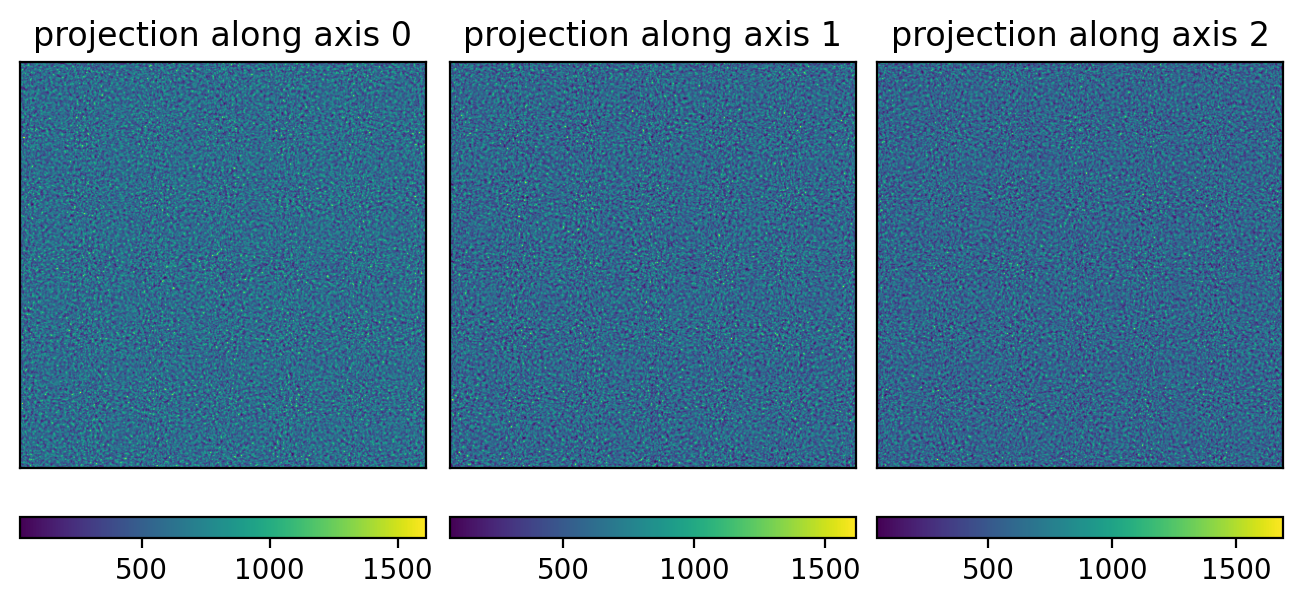

In [77]:
plot3d(ice_vol_3d)

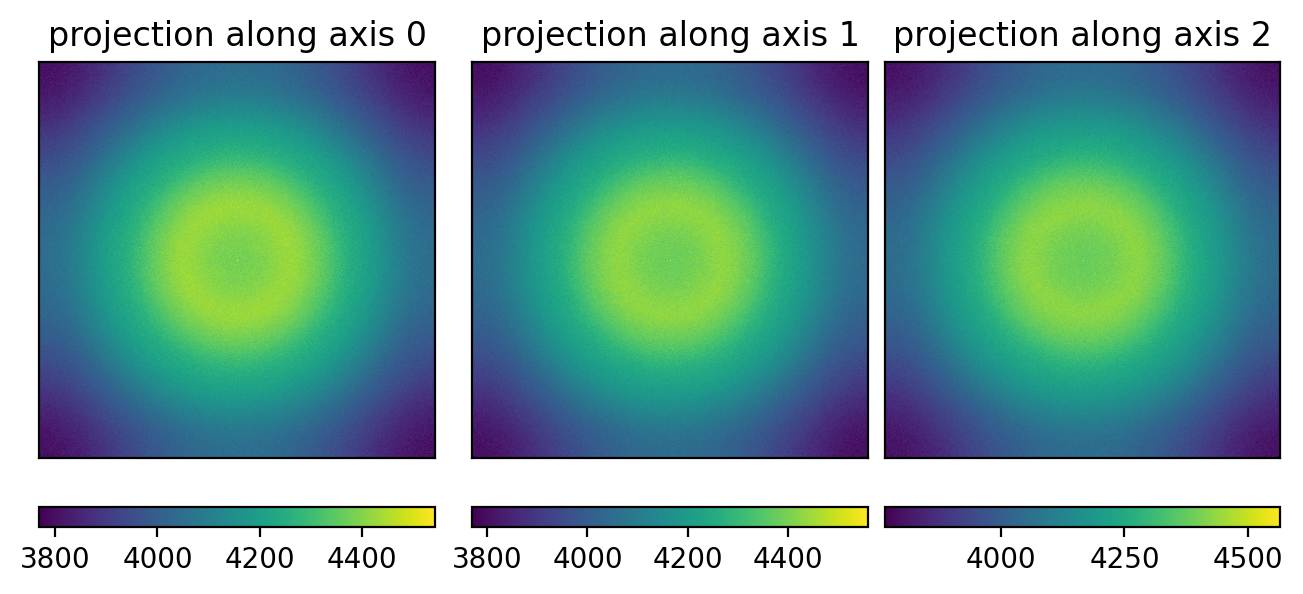

In [78]:
trimmed_vol_f = fftn(ice_vol_3d)
plot3d(torch.log(torch.abs(trimmed_vol_f)))